In [1]:
!pip install langgraph

In [13]:
from langgraph.graph import StateGraph,START,END

In [14]:
from typing import TypedDict

In [15]:
class AgentState(TypedDict):
  num1 : int
  op : str
  num2 : int
  final : int

In [23]:
def adder(state:AgentState)-> AgentState:
    """this add  two numbr """
    state['final'] = state["num1"] + state["num2"]
    return state

def sub_node(state:AgentState)-> AgentState:
    """this subtract  two numbr """
    state['final'] = state["num1"] -  state["num2"]
    return state
def decide_next_node(state:AgentState)-> AgentState:
    """this node will decide next node """
    if(state["op"] == "+"):
        return "addition_operation"
    elif(state["op"] == "-"):
        return "subtract_operation"

In [28]:
graph = StateGraph(AgentState)

graph.add_node("add_node",adder)
graph.add_node("sub_node",adder)
graph.add_node("decide_node",lambda state:state)
graph.add_edge(START,"decide_node")
graph.add_conditional_edges(
     'decide_node',
     decide_next_node,
     {
         "addition_operation":"add_node",
         "subtract_operation":"sub_node"
     }
)

graph.add_edge("add_node",END)
graph.add_edge("sub_node",END)

app = graph.compile()


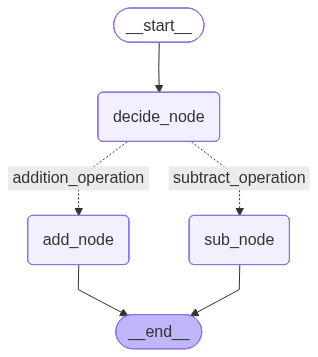

In [29]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
initial_state_1 = AgentState(num1 = 10,op = "-",num2 = 20)
print(app.invoke(initial_state_1))

{'num1': 10, 'op': '-', 'num2': 20, 'final': 30}
